In [1]:
# General Imports
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Scripts 
folder_path = os.path.abspath("scripts")
sys.path.append(folder_path)

# Derivation of Column Density Maps Routine
from Derive_Density_Maps import derive_density_maps, convert_to_mass

# Visualization Tools
from visualization_tools import show_regions_with_sections, show_Minkowski_Functionals, show_sections_OrionB_vertical, visualize_Mass_Size_D_Diagrams, visualize_Mass_Size_D_Diagramm_as_One

# Minkowski Functionals
from Minkowski_Fractal_Dimension import standard_minkowski_functionals, horizontal_marching_minkowski_functionals, vertical_marching_minkowski_functionals, intercept_corrected_minkowski_functionals 

# Box Counting 
from Box_Counting_Fractal_Dimension import box_counting

# Dendogram-like Tracker
from region_tracker import track_largest_regions, save_regions_to_pickle, load_regions_from_pickle, get_region_from_fractal_dimension_mass_and_size

# Derive Density Maps
N_H2, N_H2_OA, N_H2_OB, wcs = derive_density_maps()

[15:31:09] ERROR    PARDISO solver not installed, run `pip install pypardiso`. Otherwise,          ]8;id=917231;file://c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\openpnm\utils\_workspace.py\_workspace.py]8;;\:]8;id=120873;file://c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\openpnm\utils\_workspace.py#56\56]8;;\
                    simulations will be slow. Apple M chips not supported.                                         

# **Fractal Dimension** 

In [2]:
import numpy as np
from skimage.measure import perimeter, label, regionprops

def euler_number(mask):
    labeled = label(mask)
    regions = regionprops(labeled)
    return sum([r.euler_number for r in regions])

def standard_minkowski_functionals2(data, threshold_min=1e20, threshold_max=1e22, thresholds=None,
                                    num_samples=10, intensity_noise_std=1.0):
    """
    Compute the standard Minkowski functionals (area, perimeter, Euler characteristic)
    and fractal dimension with uncertainty using Monte Carlo sampling.

    Parameters:
    ----------
    data : numpy.ndarray
        2D array representing the dataset.
    threshold_min : float
        Minimum threshold if thresholds are auto-generated.
    threshold_max : float
        Maximum threshold if thresholds are auto-generated.
    thresholds : numpy.ndarray or None
        Array of threshold values. If None, generated logarithmically.
    num_samples : int
        Number of Monte Carlo samples per threshold.
    intensity_noise_std : float
        Standard deviation of noise added to data in each sample.

    Returns:
    -------
    dict
        Dictionary with computed values and uncertainties:
        - "thresholds"
        - "areas", "area_unc"
        - "perimeters", "perimeter_unc"
        - "euler_chars", "euler_unc"
        - "fractal_dimension", "sigma_D"
    """
    if thresholds is None:
        thresholds = np.logspace(np.log10(threshold_min), np.log10(threshold_max), 100)

    areas = []
    area_unc = []
    perimeters = []
    perimeter_unc = []
    euler_chars = []
    euler_unc = []

    for threshold in thresholds:
        area_samples = []
        perim_samples = []
        euler_samples = []

        for _ in range(num_samples):
            noisy_data = data + np.random.normal(0, intensity_noise_std, size=data.shape)
            mask = noisy_data >= threshold

            area_samples.append(np.sum(mask))
            perim_samples.append(perimeter(mask))
            euler_samples.append(euler_number(mask))

        areas.append(np.mean(area_samples))
        area_unc.append(np.std(area_samples))

        perimeters.append(np.mean(perim_samples))
        perimeter_unc.append(np.std(perim_samples))

        euler_chars.append(np.mean(euler_samples))
        euler_unc.append(np.std(euler_samples))

    # Convert to arrays
    areas = np.array(areas)
    area_unc = np.array(area_unc)
    perimeters = np.array(perimeters)
    perimeter_unc = np.array(perimeter_unc)
    euler_chars = np.array(euler_chars)
    euler_unc = np.array(euler_unc)

    # Log scale for fractal dimension
    log_areas = np.log10(areas)
    log_perimeters = np.log10(perimeters)

    valid = np.isfinite(log_areas) & np.isfinite(log_perimeters)
    slope, intercept = np.polyfit(log_perimeters[valid], log_areas[valid], 1)
    D = (2 * log_perimeters) / log_areas

    # Propagate uncertainty to fractal dimension
    dD_dP = 2 / (np.log(10) * perimeters * log_areas)
    dD_dA = -2 * log_perimeters / (np.log(10) * areas * log_areas**2)
    sigma_D = np.sqrt((dD_dP * perimeter_unc)**2 + (dD_dA * area_unc)**2)

    return {
        "thresholds": thresholds,
        "areas": areas,
        "area_unc": area_unc,
        "perimeters": perimeters,
        "perimeter_unc": perimeter_unc,
        "euler_chars": euler_chars,
        "euler_unc": euler_unc,
        "fractal_dimension": D,
        "sigma_D": sigma_D
    }


2.972512859016305
Correlation coefficient: 0.9893
Slope: 1.4863 ± 0.0221
Fractal dimension D = 1.35 ± 0.02
Average residual (very symmentrical): -0.0000
Mean absolute residual: 0.1174


c:\Users\User\anaconda3\envs\Astronomy_Env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


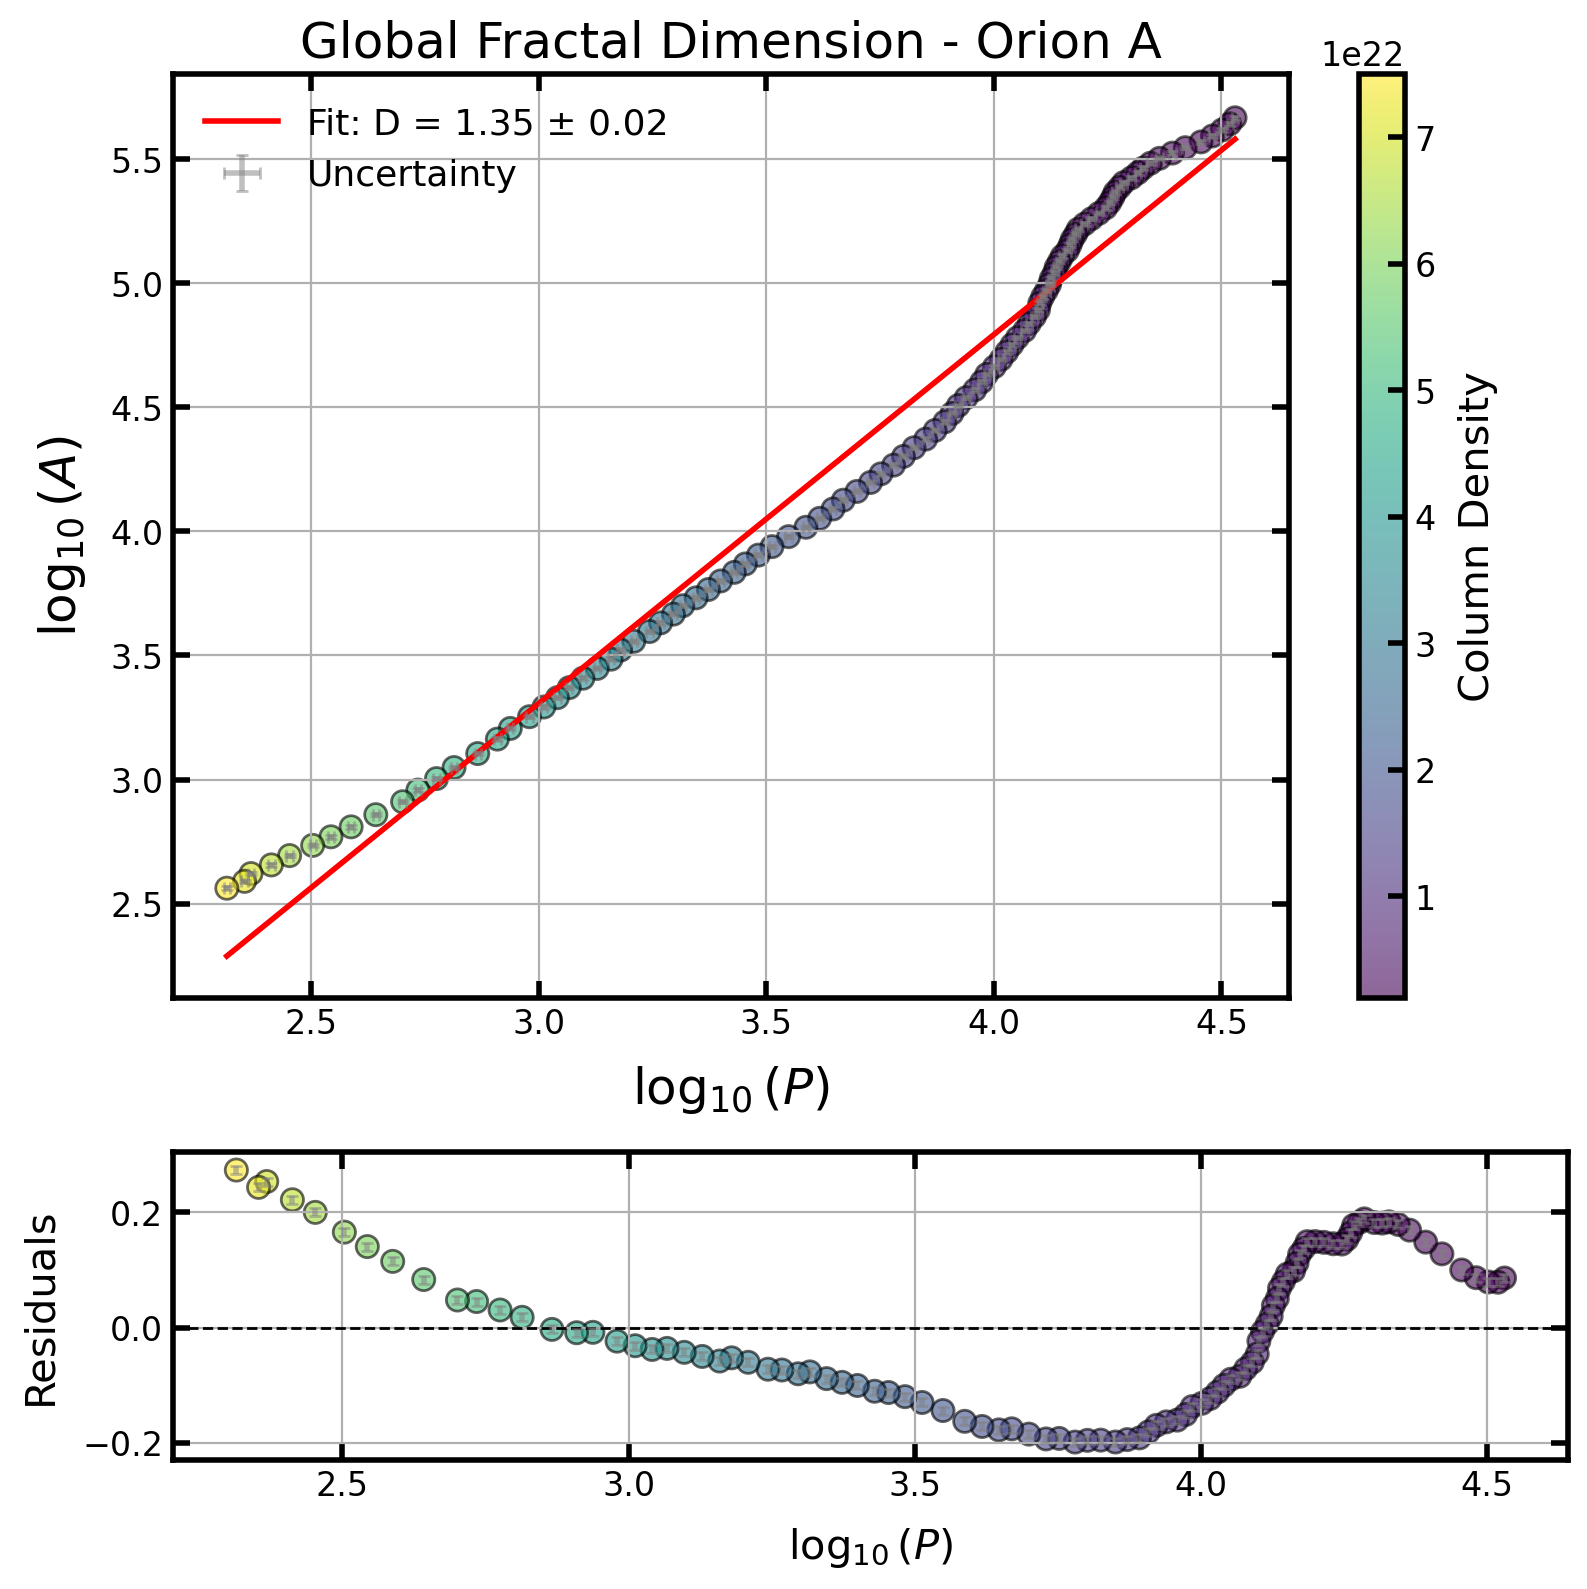

In [2]:
# global fractal dimension (Orion A)

# Orion A
region_name = "Orion A"

# range Orion A (whole)
threshold_min = 1.95e21
threshold_max = 7.5e22

# threshold_max = 1.0e23

# Minkowski
results_OA = standard_minkowski_functionals(N_H2_OA, threshold_min = threshold_min, threshold_max = threshold_max)

# Load data
perimeters = np.array(results_OA["perimeters"])
areas = np.array(results_OA["areas"])
thresholds = np.array(results_OA["thresholds"])

# Compute logs
log_perimeters = np.log10(perimeters)
log_areas = np.log10(areas)

# --- Define 1.6% relative uncertainty ---
rel_error = 0.016

# Uncertainties in P and A
sigma_P_abs = perimeters * rel_error
sigma_A_abs = areas * rel_error

# Convert to uncertainties in log10(P) and log10(A)
sigma_logP = sigma_P_abs / (perimeters * np.log(10))
sigma_logA = sigma_A_abs / (areas * np.log(10))

# Perform weighted linear regression using np.polyfit with weights
# Weight is 1 / sigma_y
weights = 1 / sigma_logA

coefficients, cov_matrix = np.polyfit(
    log_perimeters, log_areas, deg=1, w=weights, cov=True
)
slope, intercept = coefficients
slope_err = np.sqrt(cov_matrix[0,0])

# Fractal dimension
D = 2 / slope
D_err = 2 * slope_err / slope**2

# Correlation coefficient
corr_coef = np.corrcoef(log_perimeters, log_areas)[0,1]
print(f"Correlation coefficient: {corr_coef:.4f}")
print(f"Slope: {slope:.4f} ± {slope_err:.4f}")
print(f"Fractal dimension D = {D:.2f} ± {D_err:.2f}")

import matplotlib.gridspec as gridspec

# --- Plotting ---
norm = plt.Normalize(threshold_min, threshold_max)
cmap = plt.cm.viridis

# Compute residuals
residuals = log_areas - (slope * log_perimeters + intercept)

print(f"Average residual (very symmentrical): {np.mean(residuals):.4f}")
print(f"Mean absolute residual: {np.mean(np.abs(residuals)):.4f}")

# Set up figure with 2 rows: main plot + residuals
fig = plt.figure(figsize=(9,9))
gs = gridspec.GridSpec(2,1, height_ratios=[3,1], hspace=0.25)

# Top: scatter + fit
ax_main = fig.add_subplot(gs[0])

sc = ax_main.scatter(
    log_perimeters, log_areas,
    c=thresholds, cmap=cmap, norm=norm, alpha=0.6, edgecolor="k"
)
x_fit = np.linspace(np.min(log_perimeters), np.max(log_perimeters), 100)
y_fit = slope * x_fit + intercept
ax_main.plot(
    x_fit, y_fit,
    color="red", lw=2,
    label=f"Fit: D = {D:.2f} ± {D_err:.2f}"
)
ax_main.errorbar(
    log_perimeters, log_areas,
    xerr=sigma_logP, yerr=sigma_logA,
    fmt='none', ecolor='gray', alpha=0.5, capsize=2, label="Uncertainty"
)

ax_main.set_ylabel(r"$\log_{10}(A)$", fontsize=18)
ax_main.set_xlabel(r"$\log_{10}(P)$", fontsize=18)
ax_main.legend(fontsize=13)
ax_main.grid(True)
ax_main.set_title("Global Fractal Dimension - Orion A", fontsize=18)
cbar = fig.colorbar(sc, ax=ax_main)
cbar.set_label("Column Density", fontsize=15)

# Bottom: residuals
ax_res = fig.add_subplot(gs[1])
ax_res.axhline(0, color="k", lw=1, ls="--")
ax_res.scatter(
    log_perimeters, residuals,
    c=thresholds, cmap=cmap, norm=norm, alpha=0.6, edgecolor="k"
)
ax_res.errorbar(
    log_perimeters, residuals,
    yerr=sigma_logA,
    fmt='none', ecolor='gray', alpha=0.5, capsize=2
)

ax_res.set_xlabel(r"$\log_{10}(P)$", fontsize=15)
ax_res.set_ylabel("Residuals", fontsize=15)
ax_res.grid(True)

# plt.tight_layout()
plt.show()

2.859715631165698
Correlation coefficient: 0.9976
Slope: 1.4299 ± 0.0101
Fractal dimension D = 1.40 ± 0.01
Average residual (very symmentrical): -0.0000
Mean absolute residual: 0.0493


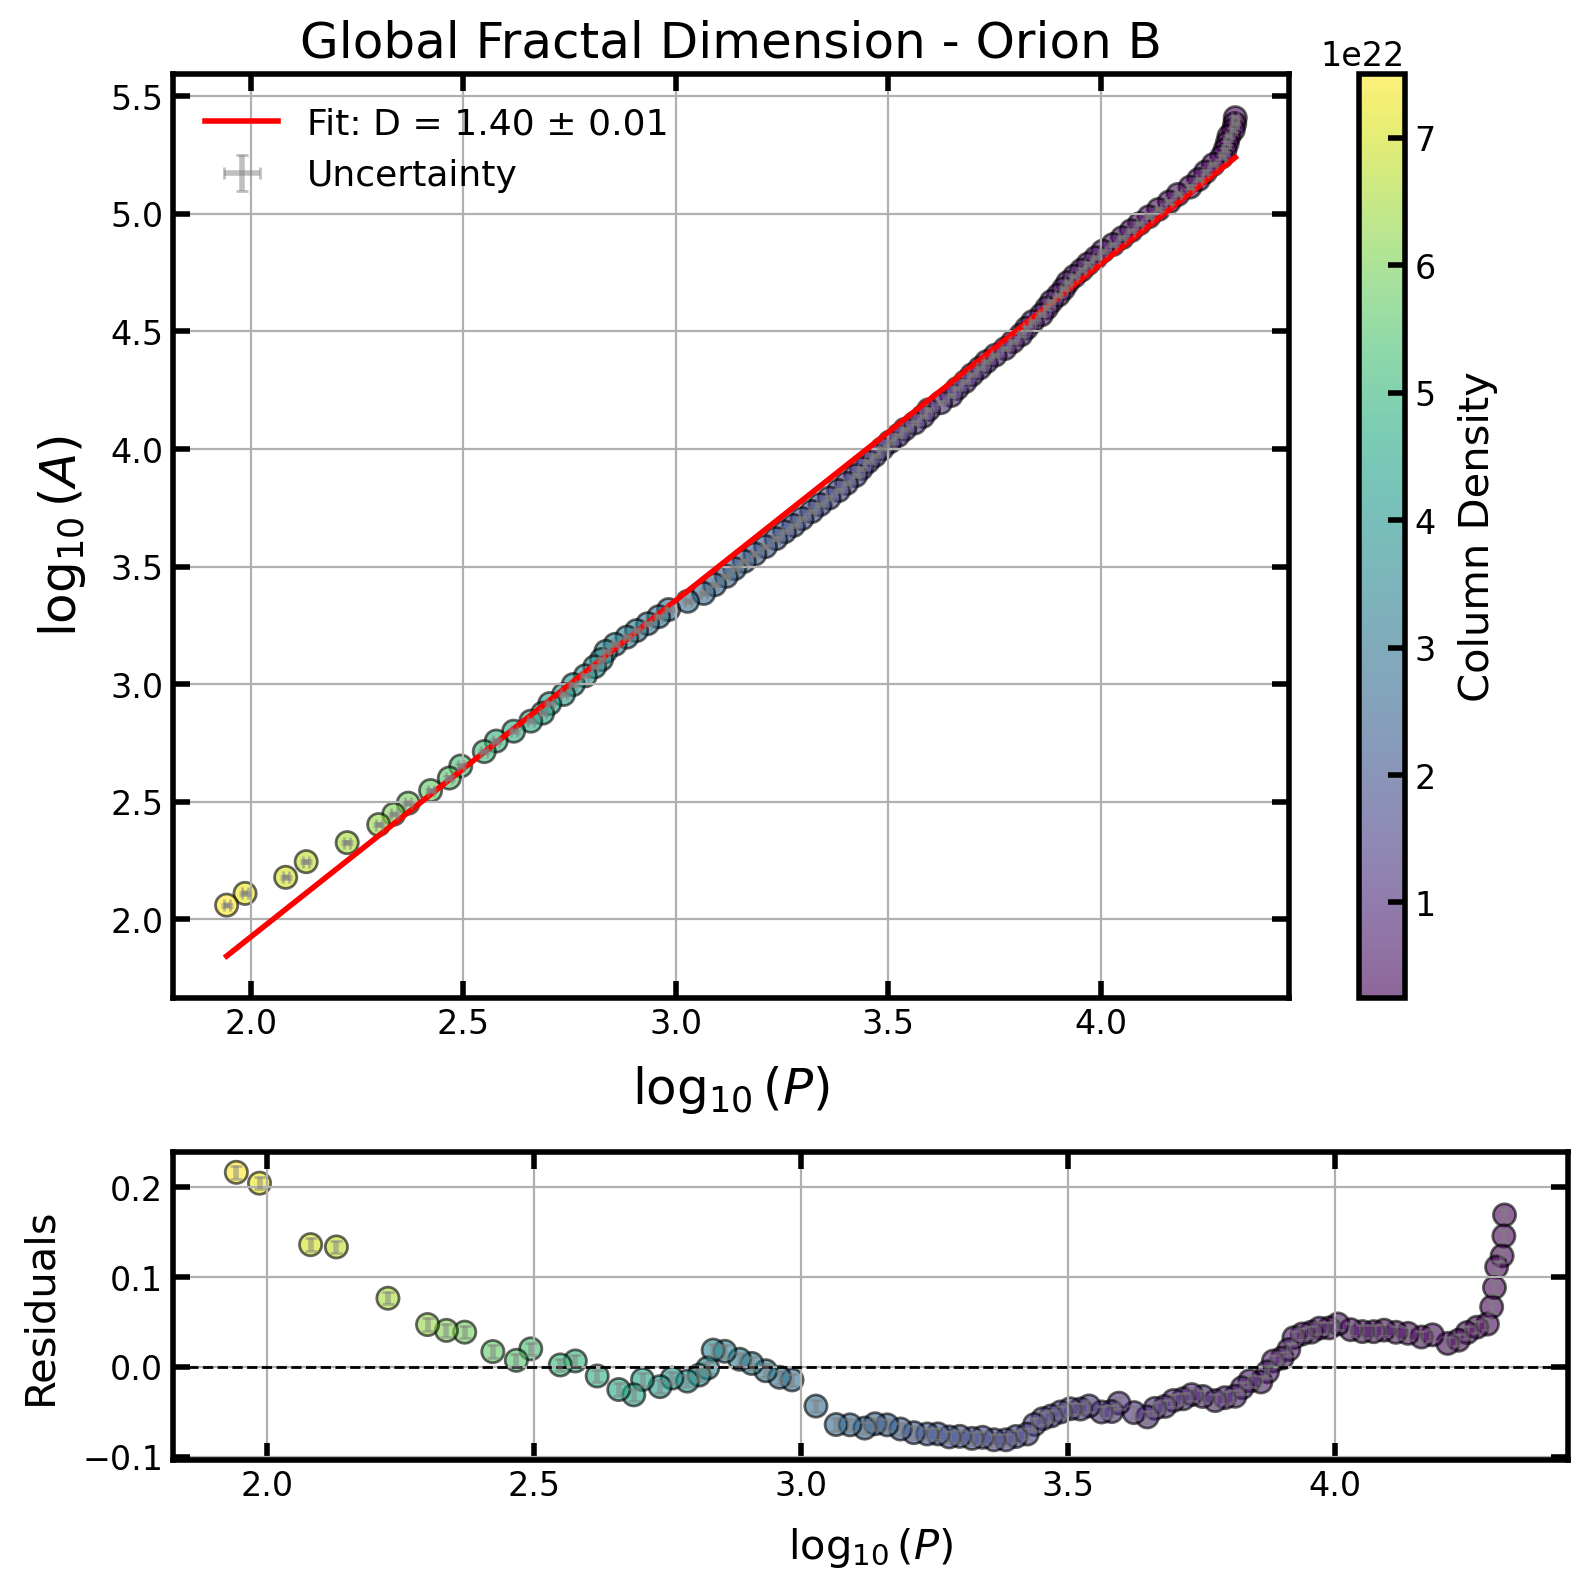

In [3]:
from scipy.stats import linregress

# global fractal dimension (Orion A)

region_name = "Orion B"

# range Orion B
threshold_min = 2.5e21
threshold_max = 7.5e22

# Minkowski
results_OB = standard_minkowski_functionals(N_H2_OB, threshold_min = threshold_min, threshold_max = threshold_max)

# Load data
perimeters = np.array(results_OB["perimeters"])
areas = np.array(results_OB["areas"])
thresholds = np.array(results_OB["thresholds"])

# Compute logs
log_perimeters = np.log10(perimeters)
log_areas = np.log10(areas)

# --- Define 1.6% relative uncertainty ---
rel_error = 0.016

# Uncertainties in P and A
sigma_P_abs = perimeters * rel_error
sigma_A_abs = areas * rel_error

# Convert to uncertainties in log10(P) and log10(A)
sigma_logP = sigma_P_abs / (perimeters * np.log(10))
sigma_logA = sigma_A_abs / (areas * np.log(10))

# Perform weighted linear regression using np.polyfit with weights
# Weight is 1 / sigma_y
weights = 1 / sigma_logA

coefficients, cov_matrix = np.polyfit(
    log_perimeters, log_areas, deg=1, w=weights, cov=True
)
slope, intercept = coefficients
slope_err = np.sqrt(cov_matrix[0,0])

# Fractal dimension
D = 2 / slope
D_err = 2 * slope_err / slope**2

# Correlation coefficient
corr_coef = np.corrcoef(log_perimeters, log_areas)[0,1]
print(f"Correlation coefficient: {corr_coef:.4f}")
print(f"Slope: {slope:.4f} ± {slope_err:.4f}")
print(f"Fractal dimension D = {D:.2f} ± {D_err:.2f}")

import matplotlib.gridspec as gridspec

# --- Plotting ---
norm = plt.Normalize(threshold_min, threshold_max)
cmap = plt.cm.viridis

# Compute residuals
residuals = log_areas - (slope * log_perimeters + intercept)

print(f"Average residual (very symmentrical): {np.mean(residuals):.4f}")
print(f"Mean absolute residual: {np.mean(np.abs(residuals)):.4f}")

# Set up figure with 2 rows: main plot + residuals
fig = plt.figure(figsize=(9,9))
gs = gridspec.GridSpec(2,1, height_ratios=[3,1], hspace=0.25)

# Top: scatter + fit
ax_main = fig.add_subplot(gs[0])

sc = ax_main.scatter(
    log_perimeters, log_areas,
    c=thresholds, cmap=cmap, norm=norm, alpha=0.6, edgecolor="k"
)
x_fit = np.linspace(np.min(log_perimeters), np.max(log_perimeters), 100)
y_fit = slope * x_fit + intercept
ax_main.plot(
    x_fit, y_fit,
    color="red", lw=2,
    label=f"Fit: D = {D:.2f} ± {D_err:.2f}"
)
ax_main.errorbar(
    log_perimeters, log_areas,
    xerr=sigma_logP, yerr=sigma_logA,
    fmt='none', ecolor='gray', alpha=0.5, capsize=2, label="Uncertainty"
)

ax_main.set_ylabel(r"$\log_{10}(A)$", fontsize=18)
ax_main.set_xlabel(r"$\log_{10}(P)$", fontsize=18)
ax_main.legend(fontsize=13)
ax_main.grid(True)
ax_main.set_title("Global Fractal Dimension - Orion B", fontsize=18)
cbar = fig.colorbar(sc, ax=ax_main)
cbar.set_label("Column Density", fontsize=15)

# Bottom: residuals
ax_res = fig.add_subplot(gs[1])
ax_res.axhline(0, color="k", lw=1, ls="--")
ax_res.scatter(
    log_perimeters, residuals,
    c=thresholds, cmap=cmap, norm=norm, alpha=0.6, edgecolor="k"
)
ax_res.errorbar(
    log_perimeters, residuals,
    yerr=sigma_logA,
    fmt='none', ecolor='gray', alpha=0.5, capsize=2
)

ax_res.set_xlabel(r"$\log_{10}(P)$", fontsize=15)
ax_res.set_ylabel("Residuals", fontsize=15)
ax_res.grid(True)

# plt.tight_layout()
plt.show()

2.972512859016305
Low log(P) <= 3.9: slope=1.209 ± 0.009, D=1.65 ± 0.01, corr=0.9986
High log(P) > 3.9: slope=2.064 ± 0.068, D=0.97 ± 0.03, corr=0.9748

Residuals summary (high N range):
Mean residual: -2.3359e-15
Mean absolute residual: 0.0222
RMS residual: 0.0295
Std deviation: 0.0295

Residuals summary (low N range):
Mean residual: -3.5350e-15
Mean absolute residual: 0.0679
RMS residual: 0.0757
Std deviation: 0.0757


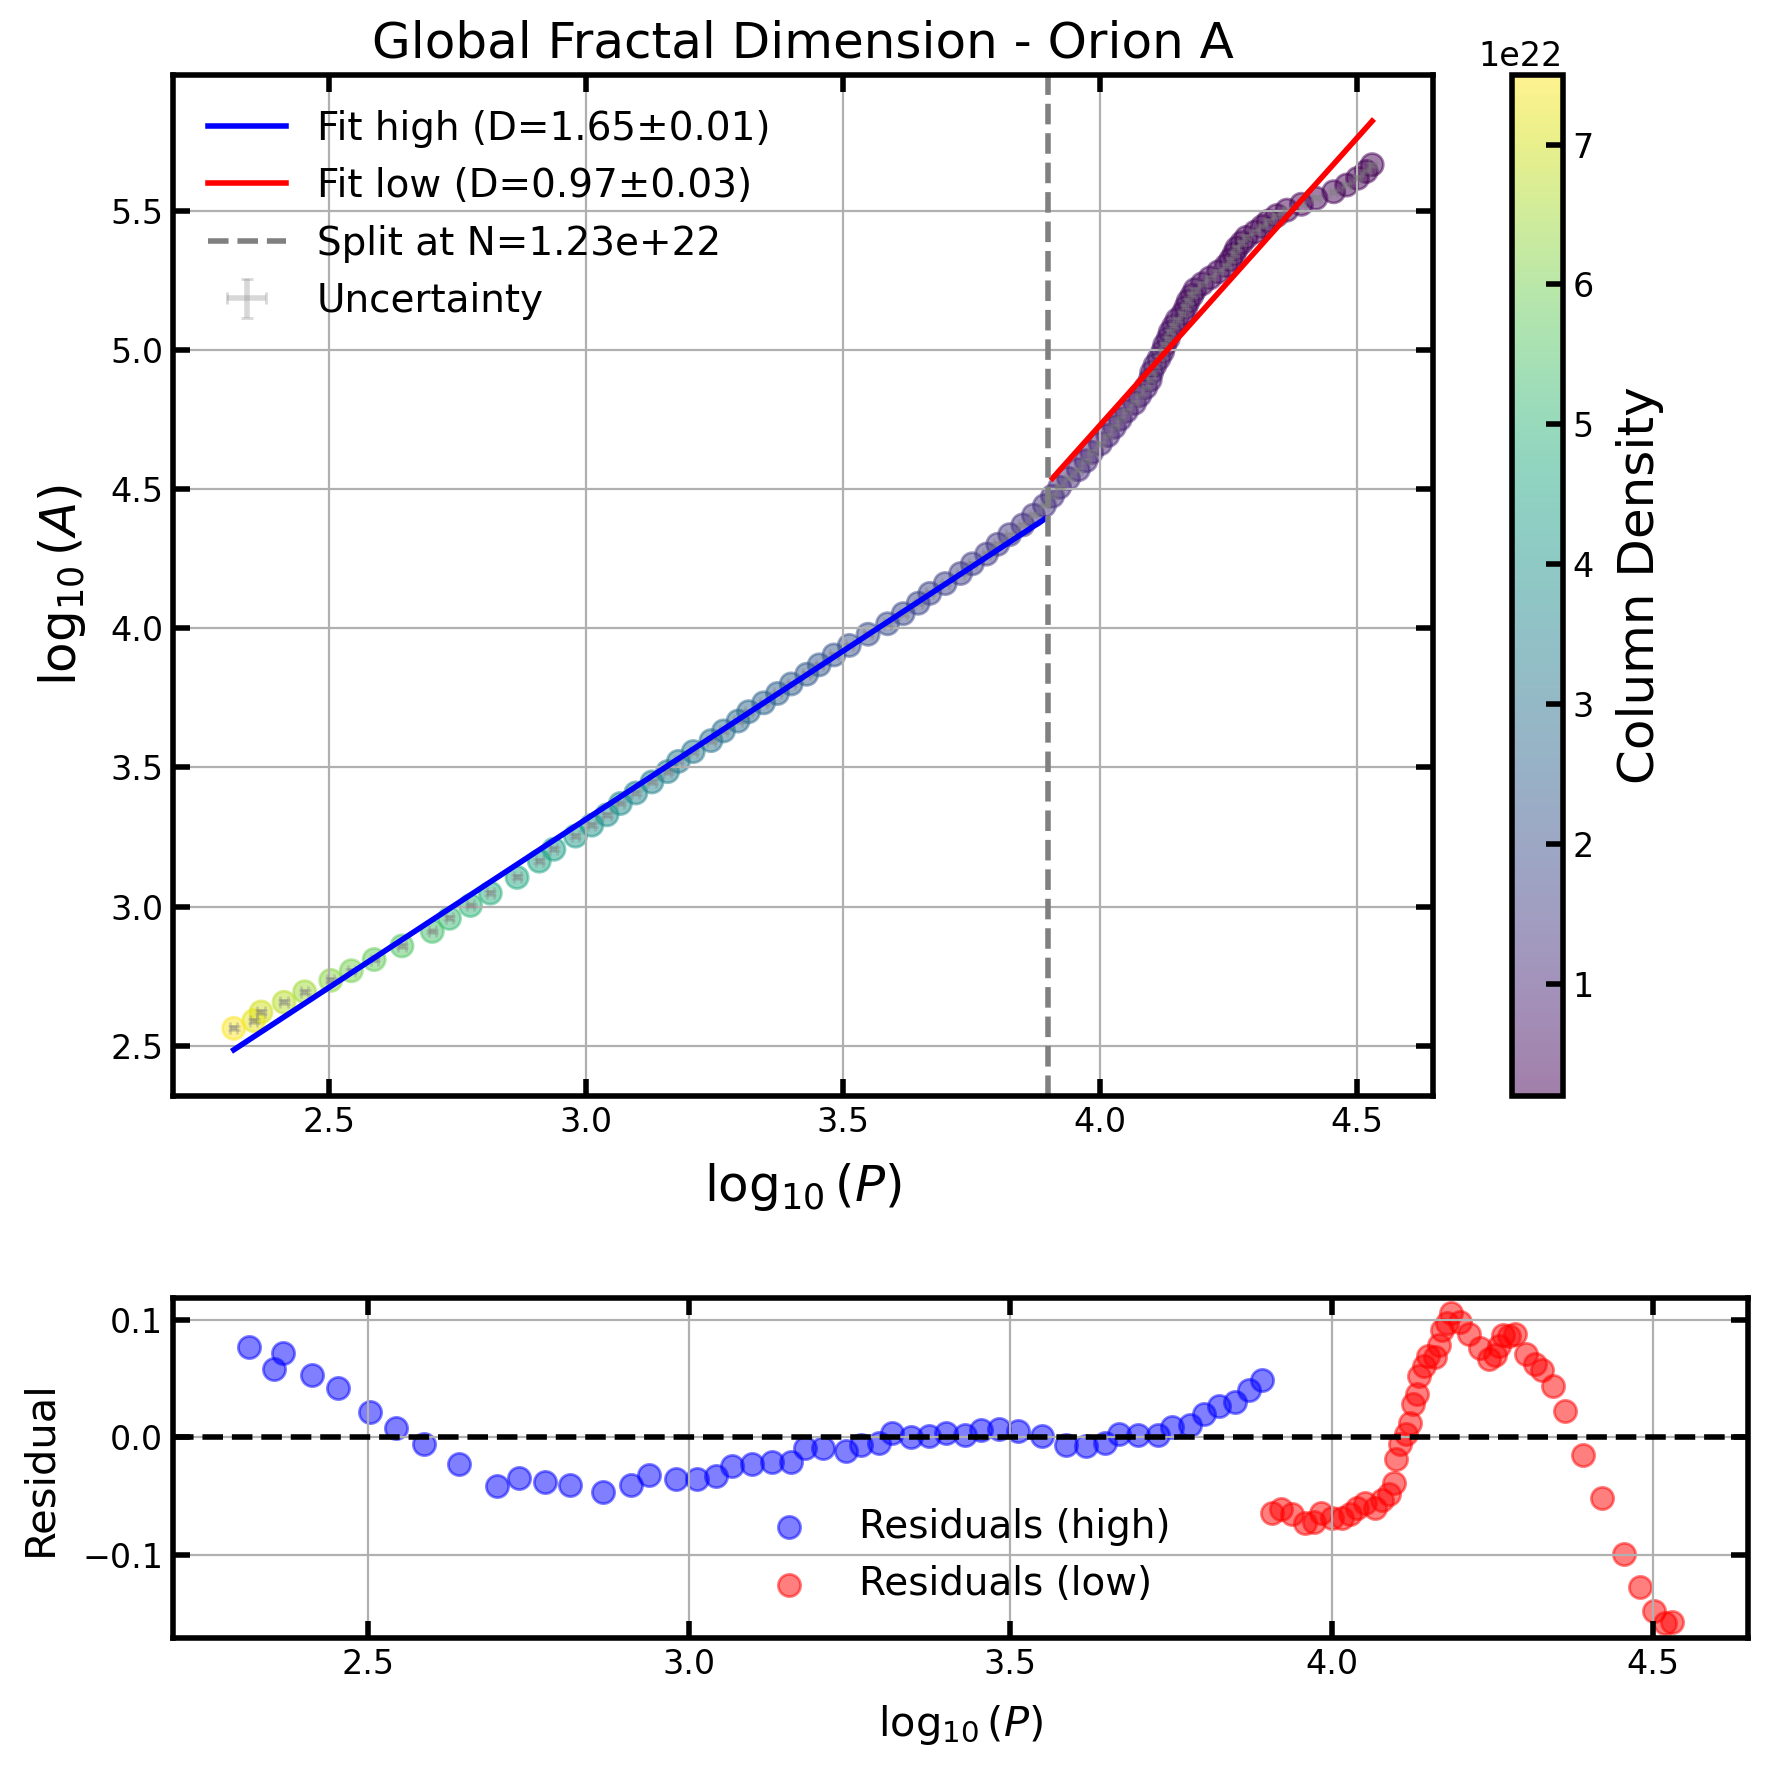

In [9]:
from scipy.stats import linregress
import numpy as np
import matplotlib.pyplot as plt

# global fractal dimension (Orion A, two fits)

# Orion A
region_name = "Orion A"

# Threshold range
threshold_min = 1.95e21
threshold_max = 7.5e22

# Minkowski
results_OA = standard_minkowski_functionals(
    N_H2_OA,
    threshold_min=threshold_min,
    threshold_max=threshold_max
)

log_perimeters = np.log10(np.array(results_OA["perimeters"]))
log_areas = np.log10(np.array(results_OA["areas"]))

# 1.6% relative uncertainty
rel_uncertainty = 0.016

# Errors in original scale
sigma_P = rel_uncertainty * np.array(results_OA["perimeters"])
sigma_A = rel_uncertainty * np.array(results_OA["areas"])

# Errors in log space
log_sigma_P = sigma_P / (np.array(results_OA["perimeters"]) * np.log(10))
log_sigma_A = sigma_A / (np.array(results_OA["areas"]) * np.log(10))

# Split data
split_value = 3.9
mask_low = log_perimeters <= split_value
mask_high = log_perimeters > split_value

# Fit low range
coeff_low = np.polyfit(log_perimeters[mask_low], log_areas[mask_low], 1)
slope_low, intercept_low = coeff_low
reg_low = linregress(log_perimeters[mask_low], log_areas[mask_low])
corr_coef_low = np.corrcoef(log_perimeters[mask_low], log_areas[mask_low])[0, 1]
slope_err_low = reg_low.stderr
D_low = 2 / slope_low
D_err_low = 2 * slope_err_low / slope_low**2

# Fit high range
coeff_high = np.polyfit(log_perimeters[mask_high], log_areas[mask_high], 1)
slope_high, intercept_high = coeff_high
reg_high = linregress(log_perimeters[mask_high], log_areas[mask_high])
corr_coef_high = np.corrcoef(log_perimeters[mask_high], log_areas[mask_high])[0, 1]
slope_err_high = reg_high.stderr
D_high = 2 / slope_high
D_err_high = 2 * slope_err_high / slope_high**2

# Print results
print(f"Low log(P) <= {split_value}: slope={slope_low:.3f} ± {slope_err_low:.3f}, D={D_low:.2f} ± {D_err_low:.2f}, corr={corr_coef_low:.4f}")
print(f"High log(P) > {split_value}: slope={slope_high:.3f} ± {slope_err_high:.3f}, D={D_high:.2f} ± {D_err_high:.2f}, corr={corr_coef_high:.4f}")

# Residuals
residuals_low = log_areas[mask_low] - (slope_low * log_perimeters[mask_low] + intercept_low)
residuals_high = log_areas[mask_high] - (slope_high * log_perimeters[mask_high] + intercept_high)

print("\nResiduals summary (high N range):")
print(f"Mean residual: {np.mean(residuals_low):.4e}")
print(f"Mean absolute residual: {np.mean(np.abs(residuals_low)):.4f}")
print(f"RMS residual: {np.sqrt(np.mean(residuals_low**2)):.4f}")
print(f"Std deviation: {np.std(residuals_low):.4f}")

print("\nResiduals summary (low N range):")
print(f"Mean residual: {np.mean(residuals_high):.4e}")
print(f"Mean absolute residual: {np.mean(np.abs(residuals_high)):.4f}")
print(f"RMS residual: {np.sqrt(np.mean(residuals_high**2)):.4f}")
print(f"Std deviation: {np.std(residuals_high):.4f}")

# Plot
fig, axs = plt.subplots(2, 1, figsize=(9, 9), height_ratios=[3, 1], sharex=True)

# Main scatter
thresholds = results_OA["thresholds"]
norm = plt.Normalize(threshold_min, threshold_max)
cmap = plt.cm.viridis

sc = axs[0].scatter(
    log_perimeters, log_areas,
    c=thresholds, cmap=cmap, norm=norm, alpha=0.5
)

# Error bars
axs[0].errorbar(
    log_perimeters, log_areas,
    xerr=log_sigma_P, yerr=log_sigma_A,
    fmt="none", ecolor="gray", alpha=0.3, capsize=2, label="Uncertainty"
)

# Fits
x_low = np.linspace(log_perimeters[mask_low].min(), log_perimeters[mask_low].max(), 100)
x_high = np.linspace(log_perimeters[mask_high].min(), log_perimeters[mask_high].max(), 100)

axs[0].plot(x_low, slope_low * x_low + intercept_low, color="blue", label=f"Fit high (D={D_low:.2f}±{D_err_low:.2f})")
axs[0].plot(x_high, slope_high * x_high + intercept_high, color="red", label=f"Fit low (D={D_high:.2f}±{D_err_high:.2f})")

# Split marker
split_idx = np.abs(log_perimeters - split_value).argmin()
split_threshold = thresholds[split_idx]
axs[0].axvline(split_value, color="gray", linestyle="--", label=f"Split at N={split_threshold:.2e}")

# Axis labels
cbar = fig.colorbar(sc, ax=axs[0])
cbar.set_label("Column Density", fontsize=18)

axs[0].set_title("Global Fractal Dimension - Orion A", fontsize=18)
axs[0].set_ylabel(r"$\log_{10}(A)$", fontsize=18)
axs[0].set_xlabel(r"$\log_{10}(P)$", fontsize=18)

axs[0].tick_params(axis='x', which='both', bottom=True, top=True, labelbottom=True)

axs[0].legend(fontsize=14)
axs[0].grid(True)

# Residuals plot
axs[1].scatter(log_perimeters[mask_low], residuals_low, color="blue", alpha=0.5, label="Residuals (high)")
axs[1].scatter(log_perimeters[mask_high], residuals_high, color="red", alpha=0.5, label="Residuals (low)")
axs[1].axhline(0, color="black", linestyle="--")
axs[1].set_xlabel(r"$\log_{10}(P)$", fontsize=15)
axs[1].set_ylabel("Residual", fontsize=15)
axs[1].legend(fontsize=14)
axs[1].grid(True)

plt.tight_layout(h_pad=2.5)
plt.show()

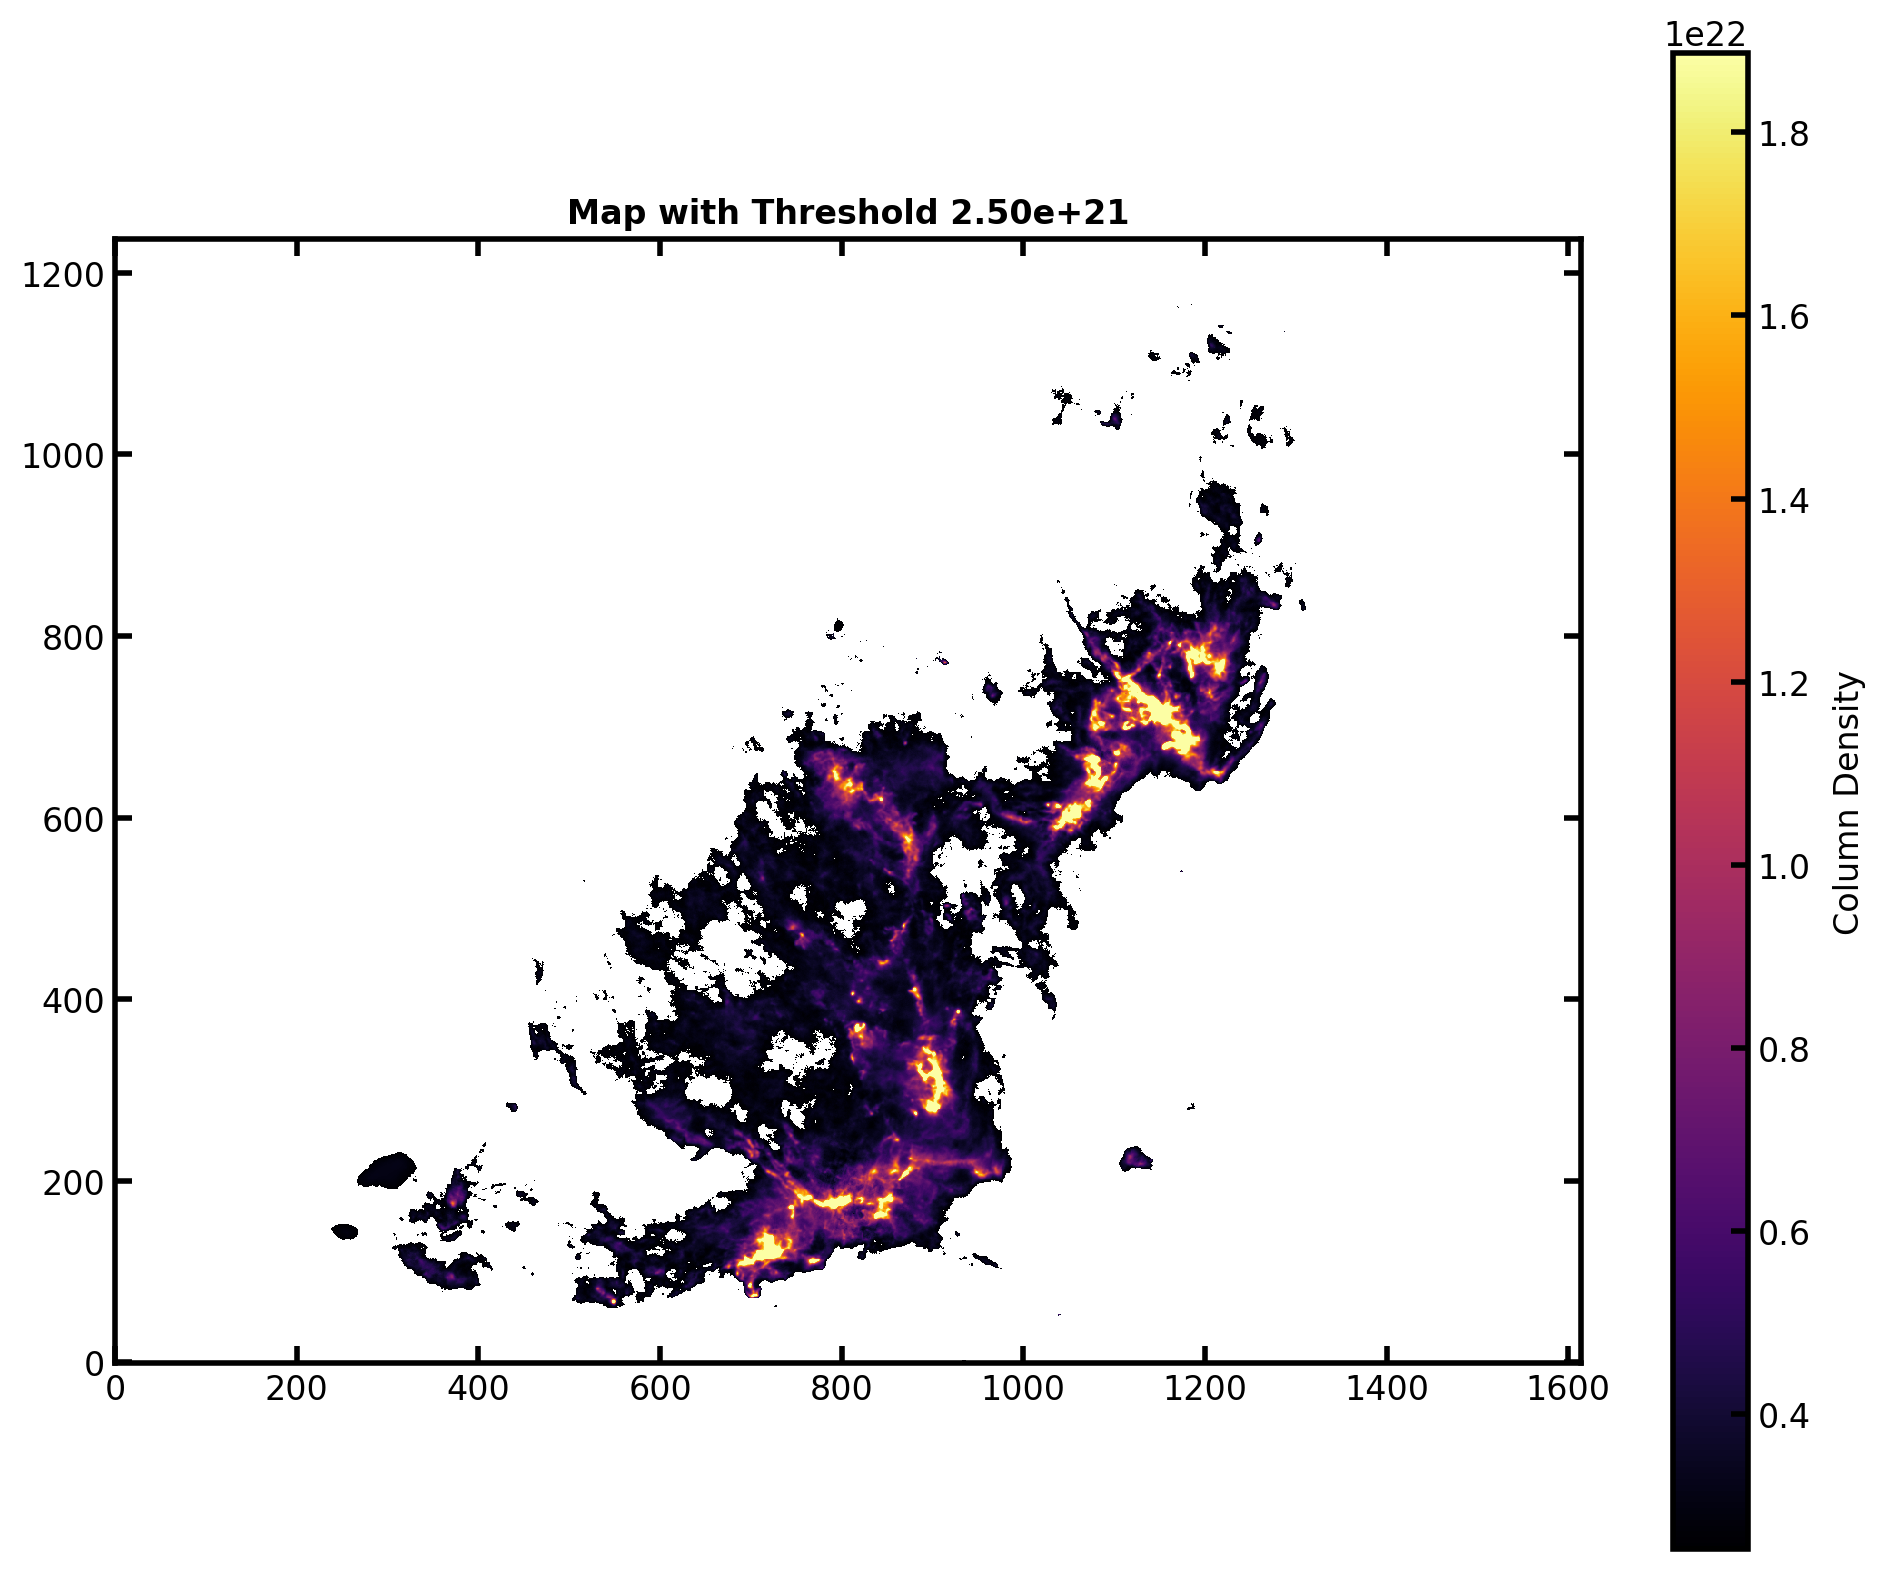

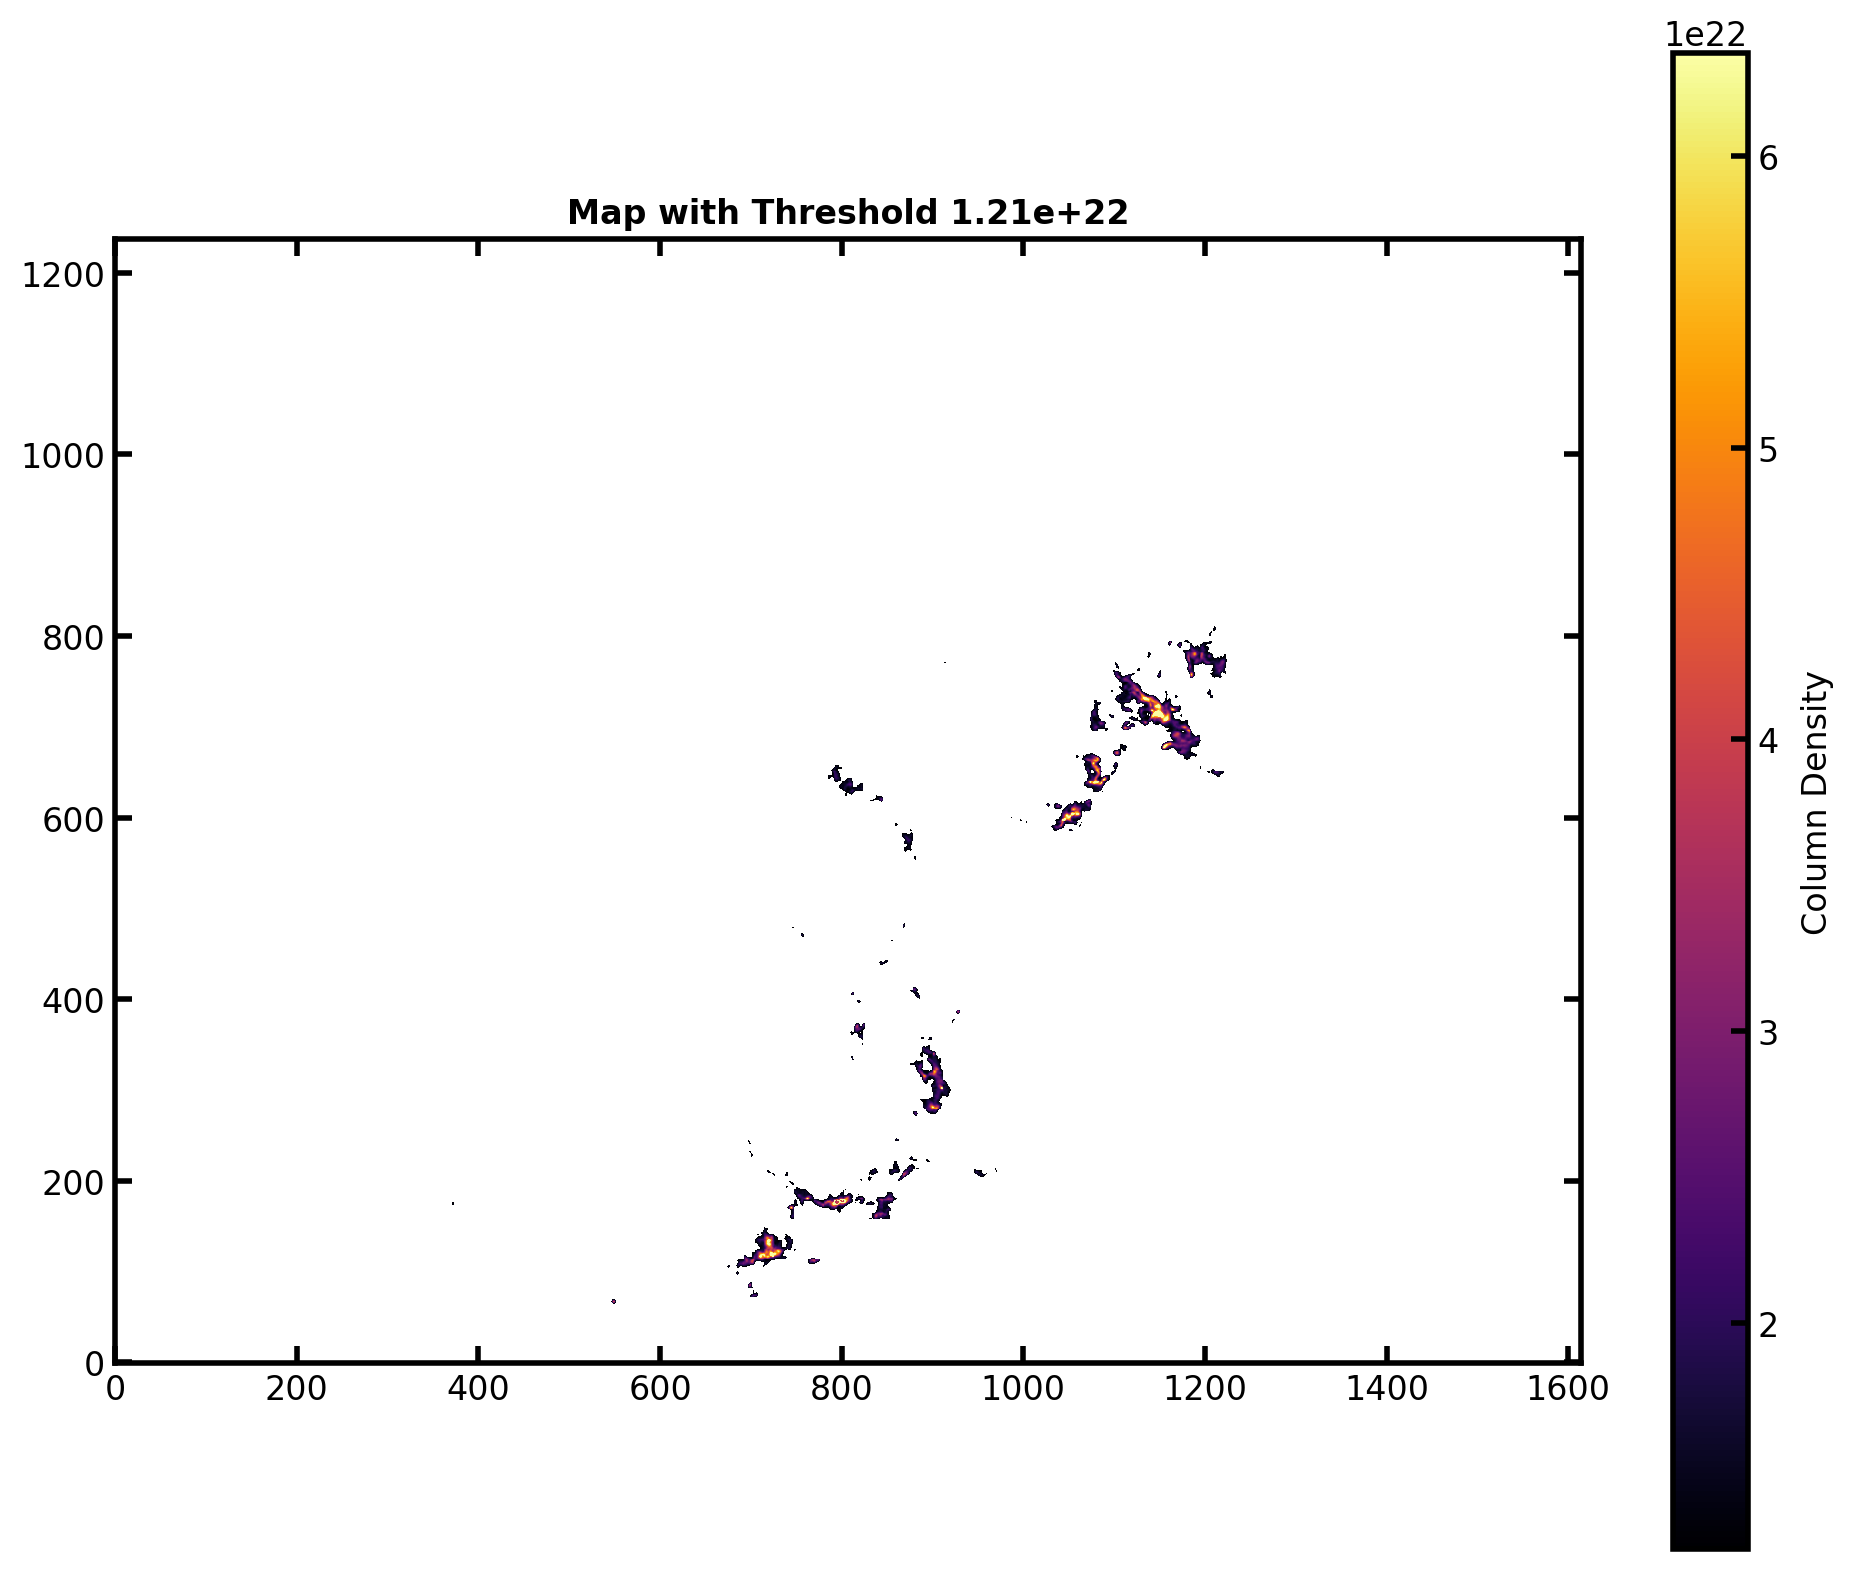

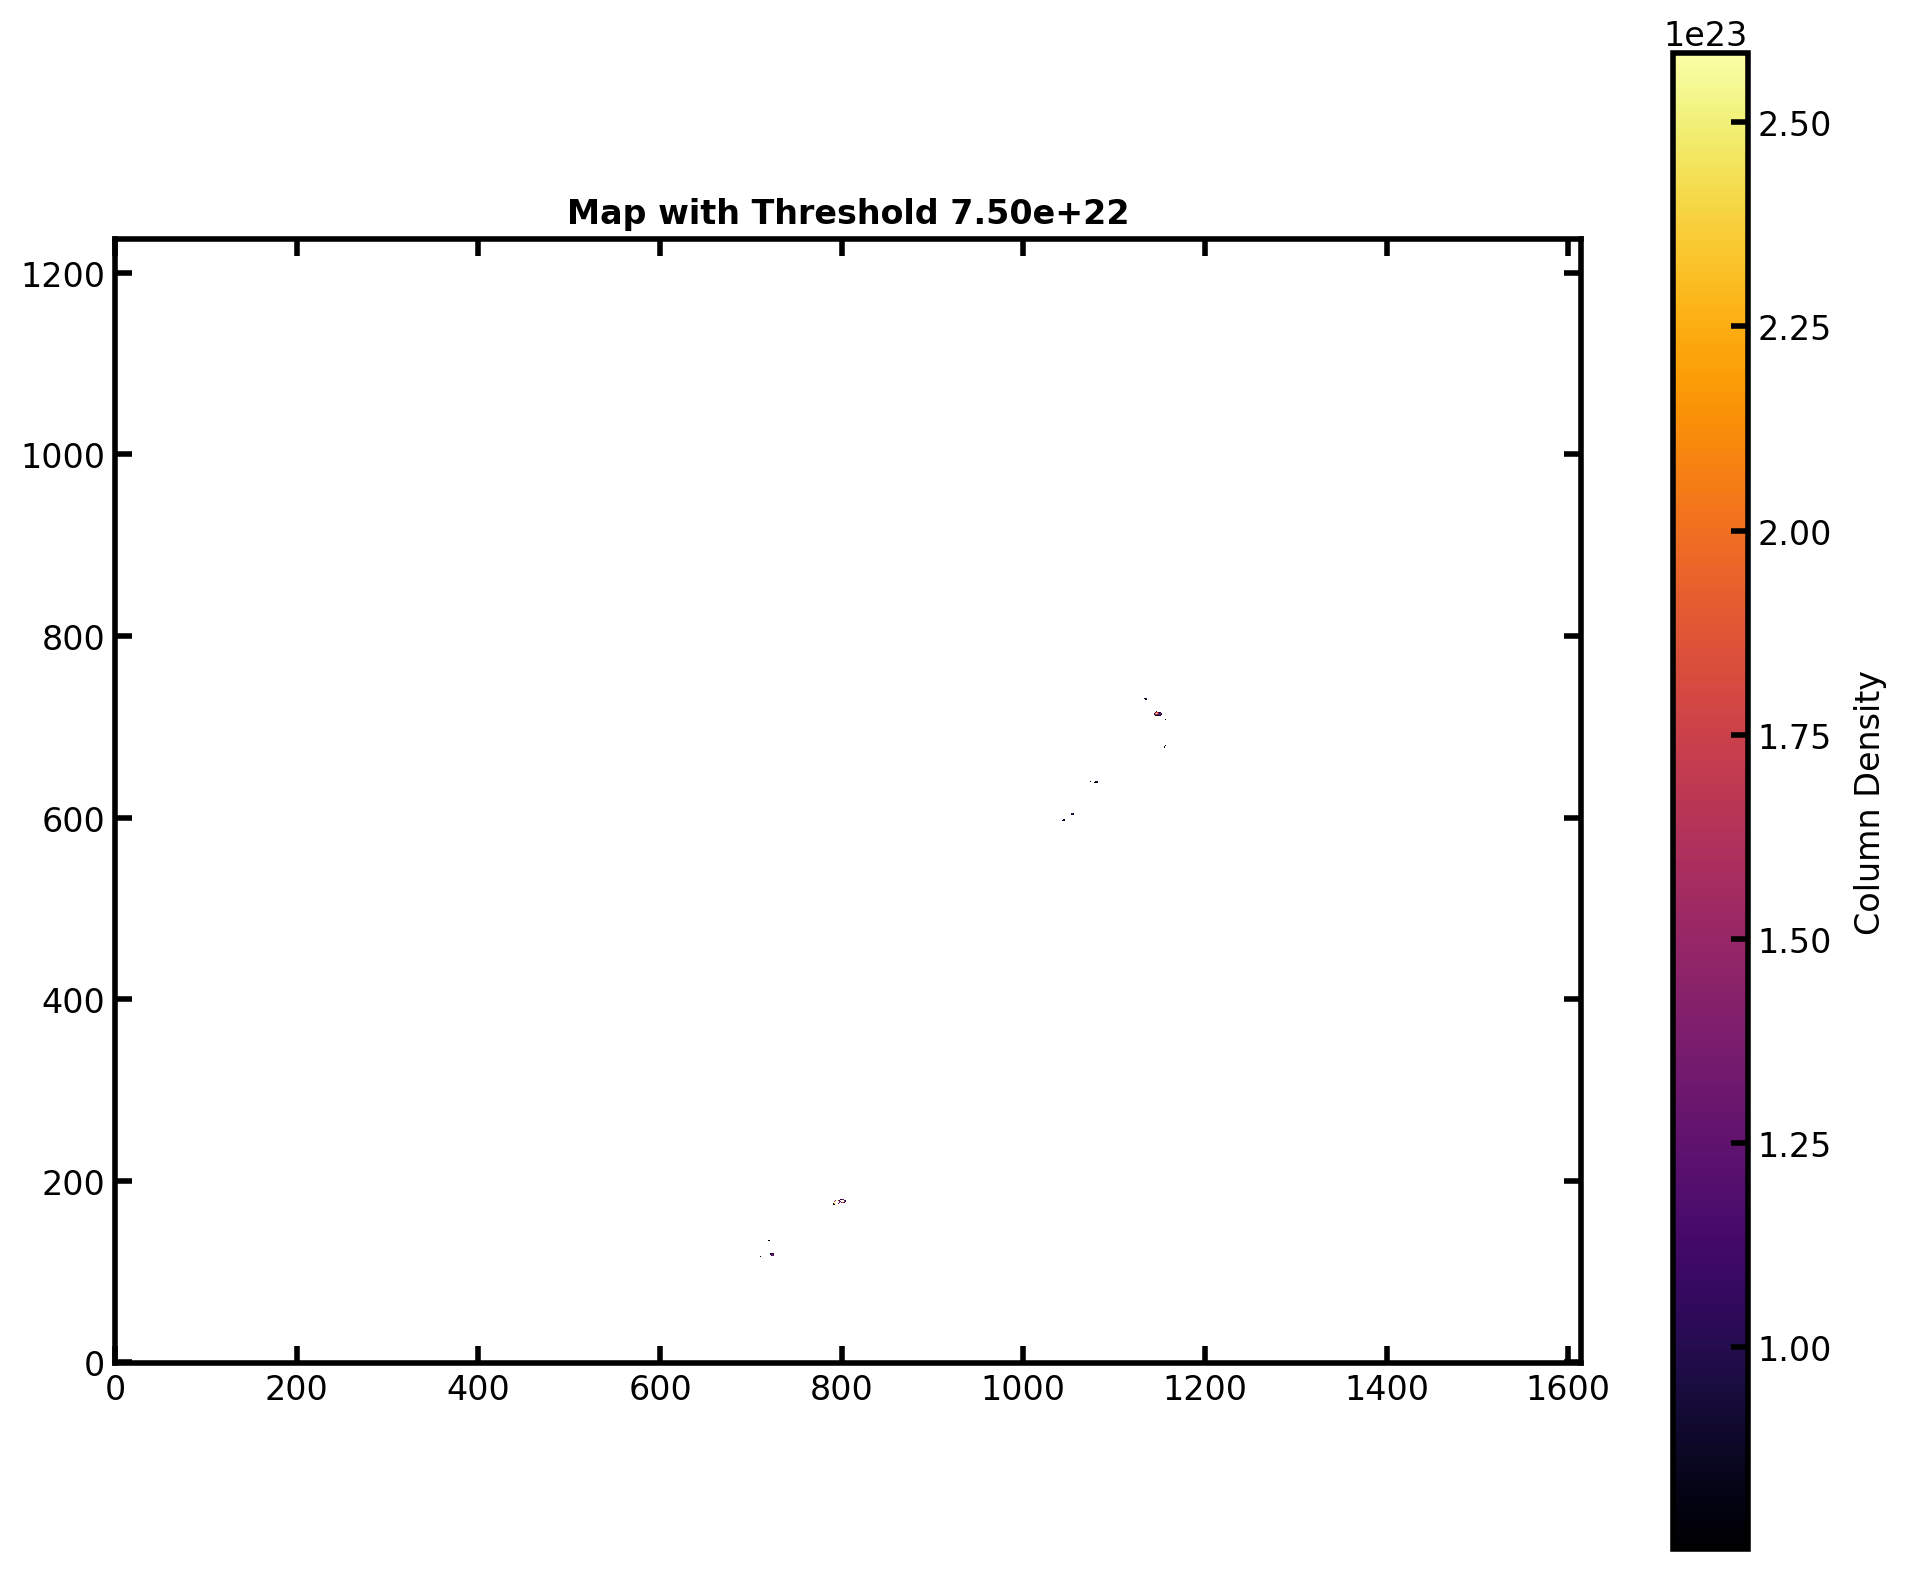

In [6]:
show_regions_with_sections(N_H2_OB, n_regions= 0, thresholds=[2.5e21, 1.21e22, 7.5e22])

# **Euler Characteristic**

In [7]:
from GRF import generate_gaussian_random_field

# overall, these work best for the whole region
threshold_min = 2.5e21
threshold_max = 7.5e22 # This works well when the fractal dimension is calculated for the whole region, but for the individual regions it might be good to go further down

thresholds_OA = np.linspace(threshold_min, threshold_max, 100)

# Minkowski
results_OA = standard_minkowski_functionals(N_H2_OA)
results_OB = standard_minkowski_functionals(N_H2_OB)

# GRF, _ = generate_gaussian_random_field(512, a=-2)

# thresholds_GRF = np.linspace(np.min(GRF), np.max(GRF), 100)

# results_GRF = standard_minkowski_functionals(GRF)

0.682585707254066


KeyboardInterrupt: 

C:\Users\User\AppData\Local\Temp\ipykernel_6420\2425883042.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


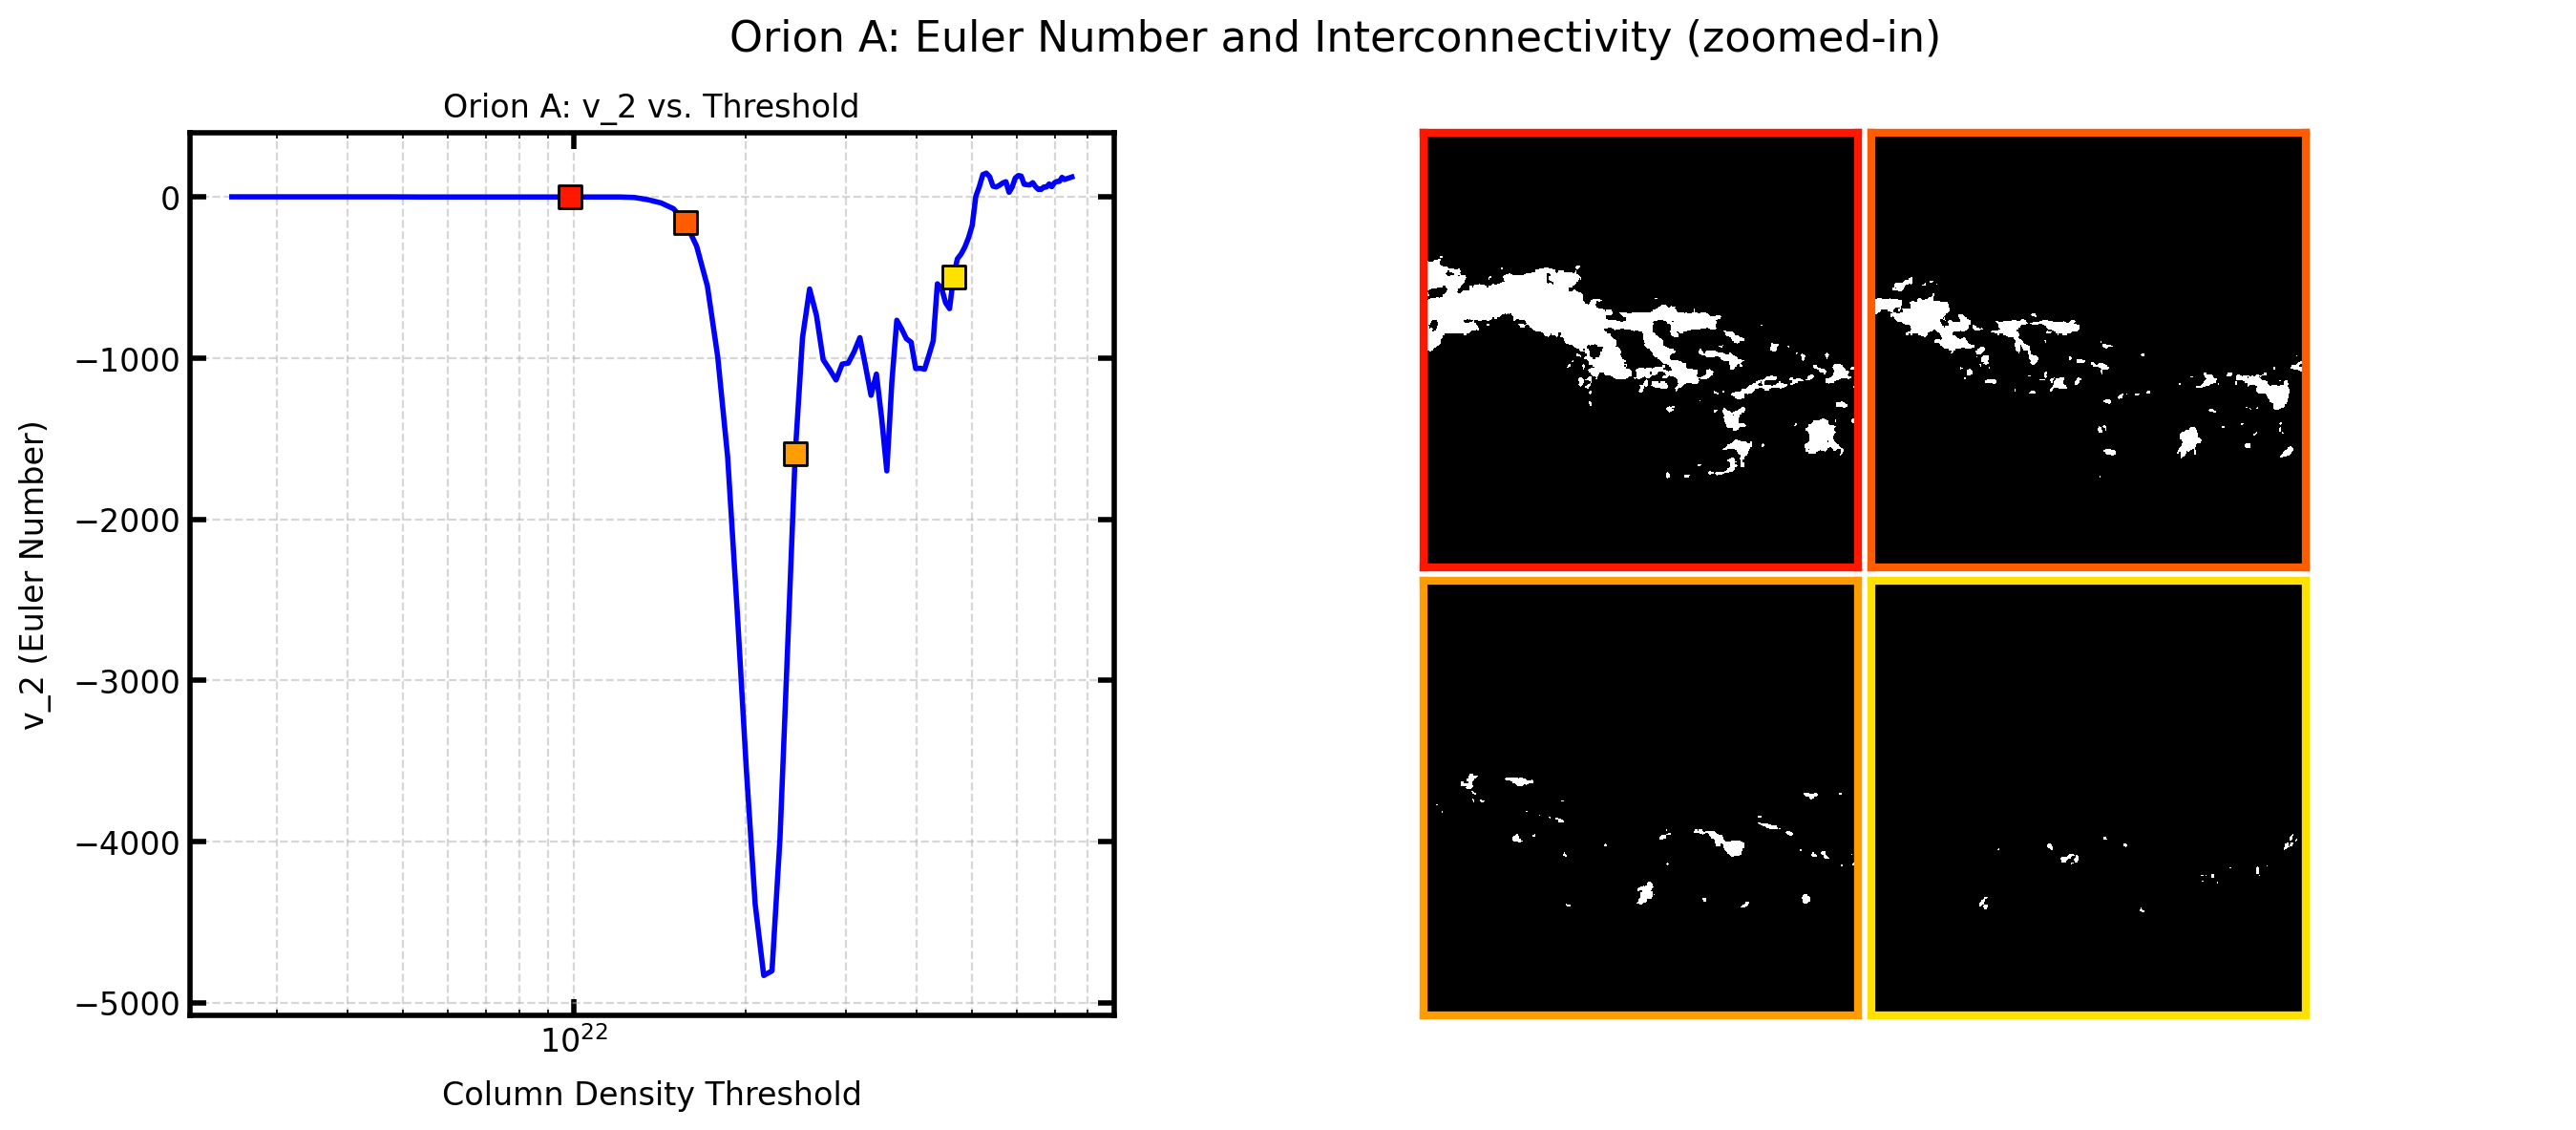

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1 import ImageGrid

def slice_around_mask_center(mask, zoom_pixels=200):
    """
    Returns a slice around the center of the mask region with a fixed zoom size.
    
    Parameters:
        mask (2D array): Binary mask (e.g., structure >= threshold)
        zoom_pixels (int): Half-width/height of the zoom box in pixels
        
    Returns:
        y_slice, x_slice: slice objects to index the region
    """
    y, x = np.where(mask)
    if len(x) == 0 or len(y) == 0:
        # fallback: center of the full image
        center_y, center_x = mask.shape[0] // 2, mask.shape[1] // 2
    else:
        # center of the structure
        center_y = int(np.mean(y))
        center_x = int(np.mean(x))

    y_min = max(center_y - zoom_pixels, 0)
    y_max = min(center_y + zoom_pixels, mask.shape[0])
    x_min = max(center_x - zoom_pixels, 0)
    x_max = min(center_x + zoom_pixels, mask.shape[1])

    return slice(y_min, y_max), slice(x_min, x_max)


def plot_euler_and_structures(data, thresholds, euler_results, title_prefix, example_threshold_indices, cmap='gray'):
    fig = plt.figure(figsize=(16, 6))

    # Create a gridspec to place the main plot and image grid
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.5], wspace=0.05)

    # Left: Euler number vs threshold
    ax_curve = fig.add_subplot(gs[0])
    ax_curve.plot(thresholds, euler_results, color='blue')
    ax_curve.set_xscale("log")
    ax_curve.set_xlabel("Column Density Threshold")
    ax_curve.set_ylabel("v_2 (Euler Number)")
    ax_curve.set_title(f"{title_prefix}: v_2 vs. Threshold")
    ax_curve.grid(True, which="both", ls="--", alpha=0.5)

    # Mark the selected thresholds
    colors = plt.cm.hot(np.linspace(0.4, 0.7, len(example_threshold_indices)))
    for idx, color in zip(example_threshold_indices, colors):
        ax_curve.scatter(thresholds[idx], euler_results[idx], color=color, s=70, edgecolor='black', zorder=5, marker="s")

    # Right: 2x2 grid of structure examples
    ax_grid_container = fig.add_subplot(gs[1])
    ax_grid_container.axis('off')  # Remove container axis

    grid = ImageGrid(fig, gs[1], nrows_ncols=(2, 2), axes_pad=0.07, share_all=True, cbar_mode=None)

    for ax, idx, color in zip(grid, example_threshold_indices, colors):
        mask = data >= thresholds[idx]

        y_slice, x_slice = slice_around_mask_center(mask)

        ax.imshow(mask[y_slice, x_slice], cmap=cmap, origin='lower')
        # ax.imshow(mask, origin='lower', cmap='inferno')
        # ax.set_title(f"Threshold = {thresholds[idx]:.2e}\nEuler = {euler_results[idx]}")
        # Set border color
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(3)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xticklabels([])
        ax.set_yticklabels([])

    plt.suptitle(f"{title_prefix}: Euler Number and Interconnectivity (zoomed-in)", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

example_indices_OA = [10, 18, 30, 60]
plot_euler_and_structures(N_H2_OA, thresholds_OA, results_OA["euler_chars"], "Orion A", example_indices_OA)
